In [155]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras as k
import matplotlib.pyplot as plt

Caricare il Nuovo Dataset CSV (10.000 campioni)

In [156]:

DATA_CSV = "Data/features_3_sec.csv"  # Cambia con il tuo file
df = pd.read_csv(DATA_CSV)

Pre-elaborazione dei Dati

In [157]:
feature_cols = [col for col in df.columns if col not in ['filename', 'label']]
X = df[feature_cols].values.astype(float)
y = df['label'].values

Convertire le etichette in numeri interi

In [158]:
# Convertire le etichette in numeri interi
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Standardizzazione (Z-score normalization)
scaler = StandardScaler()
X = scaler.fit_transform(X)

Suddivisione in Train (70%), Validation (20%) e Test (10%)

In [159]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.7, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.66, stratify=y_temp, random_state=42)

1 modello

In [169]:
model_1 = k.models.Sequential([
    k.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dense(128, activation='relu'),
    k.layers.Dense(64, activation='relu'),
    k.layers.Dense(10, activation='softmax'),
  
])
print(model_1.summary())


Model: "sequential_63"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_290 (Dense)               │ (None, 256)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_291 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_292 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_293 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,906 (222.29 KB)

 Trainable params: 56,906 (222.29 KB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3874 - loss: 1.7742 - val_accuracy: 0.6345 - val_loss: 1.0641
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6873 - loss: 0.9218 - val_accuracy: 0.7361 - val_loss: 0.8170
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7663 - loss: 0.6889 - val_accuracy: 0.7690 - val_loss: 0.7085
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8146 - loss: 0.5596 - val_accuracy: 0.7872 - val_loss: 0.6429
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8449 - loss: 0.4726 - val_accuracy: 0.8074 - val_loss: 0.5962
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8705 - loss: 0.4032 - val_accuracy: 0.8180 - val_loss: 0.5643
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8936 - loss: 0.3481 - val_accuracy: 0.8301 - val_loss: 0.5427
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9066 - loss: 0.3026 - val_accuracy: 0.8342 - v

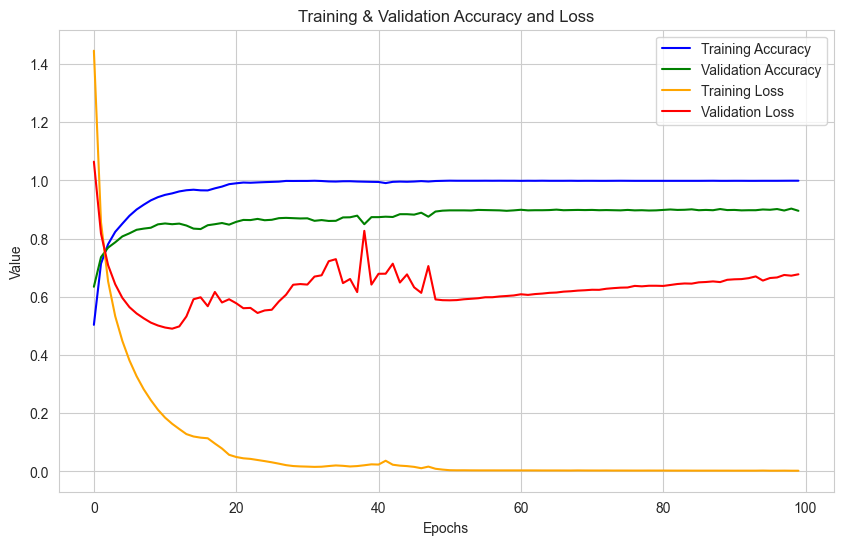

In [170]:
# 5️⃣ Compilazione del Modello
model_1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# 7️⃣ Allenamento del Modello
history = model_1.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=100, batch_size=128, verbose=1)

# 8️⃣ Valutazione
test_loss, test_acc = model_1.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print("The test Loss is :",test_loss)



# 9️⃣ Grafico Unico con Training Accuracy, Validation Accuracy, Training Loss, Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.plot(history.history['loss'], label='Training Loss', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')

plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Training & Validation Accuracy and Loss")
plt.legend()
plt.grid(True)
plt.show()

In [163]:
model_2 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.2),
    
    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(10, activation='softmax'),
])
print(model_2.summary())

Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_275 (Dense)               │ (None, 512)            │        30,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_188 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_276 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_189 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_277 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_190 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_278 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_191 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_279 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,338 (794.29 KB)

 Trainable params: 203,338 (794.29 KB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3103 - loss: 1.8776 - val_accuracy: 0.6006 - val_loss: 1.1282
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5802 - loss: 1.1901 - val_accuracy: 0.7007 - val_loss: 0.9210
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6731 - loss: 0.9633 - val_accuracy: 0.7523 - val_loss: 0.7836
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7317 - loss: 0.8046 - val_accuracy: 0.7674 - val_loss: 0.7134
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7546 - loss: 0.7260 - val_accuracy: 0.7882 - val_loss: 0.6648
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7931 - loss: 0.6284 - val_accuracy: 0.8109 - val_loss: 0.6085
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8149 - loss: 0.5640 - val_accuracy: 0.8124 - val_loss: 0.5755
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8254 - loss: 0.5235 - val_accuracy: 0.8236 - v

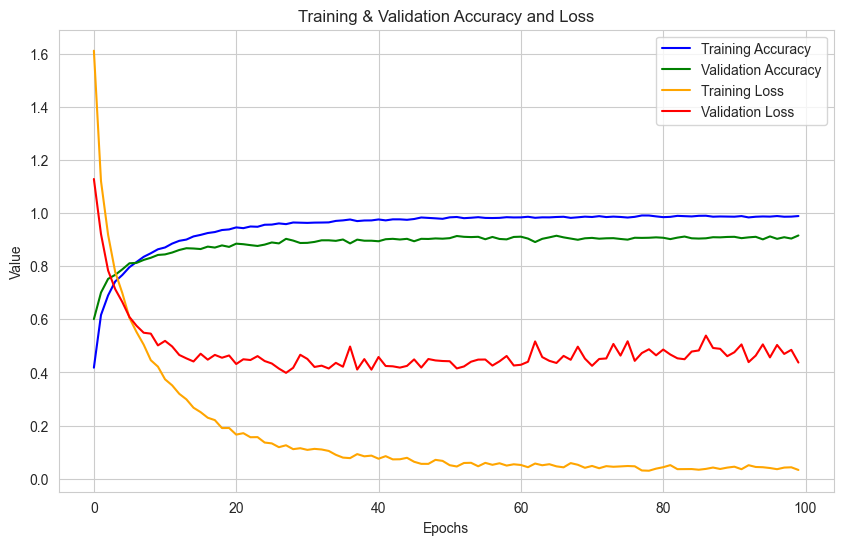

In [164]:
# 5️⃣ Compilazione del Modello
model_2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# 7️⃣ Allenamento del Modello
history = model_2.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=100, batch_size=128, verbose=1)

# 8️⃣ Valutazione
test_loss, test_acc = model_2.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print("The test Loss is :",test_loss)

# 9️⃣ Grafico Unico con Training Accuracy, Validation Accuracy, Training Loss, Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.plot(history.history['loss'], label='Training Loss', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')

plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Training & Validation Accuracy and Loss")
plt.legend()
plt.grid(True)
plt.show()

In [212]:
#  Creazione della Neural Network (con Batch Normalization)
model = keras.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(len(np.unique(y)), activation='softmax')  # Output con softmax per classificazione
])
print(model.summary())

Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_389 (Dense)               │ (None, 512)            │        30,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_231         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_276 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_390 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_232         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_277 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_391 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_233         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_278 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_392 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_234         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_279 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_393 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,178 (809.29 KB)

 Trainable params: 205,258 (801.79 KB)

 Non-trainable params: 1,920 (7.50 KB)

None


Epoch 1/400
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1348 - loss: 2.9330 - val_accuracy: 0.2594 - val_loss: 2.1548
Epoch 2/400
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2409 - loss: 2.3724 - val_accuracy: 0.3271 - val_loss: 1.9691
Epoch 3/400
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3184 - loss: 2.0648 - val_accuracy: 0.4216 - val_loss: 1.7616
Epoch 4/400
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3606 - loss: 1.8878 - val_accuracy: 0.4823 - val_loss: 1.5665
Epoch 5/400
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3945 - loss: 1.7601 - val_accuracy: 0.5379 - val_loss: 1.4092
Epoch 6/400
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4307 - loss: 1.6556 - val_accuracy: 0.5718 - val_loss: 1.3011
Epoch 7/400
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4612 - loss: 1.5731 - val_accuracy: 0.5940 - val_loss: 1.2243
Epoch 8/400
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4776 - loss: 1.5331 - val_accuracy: 0.6132 - v

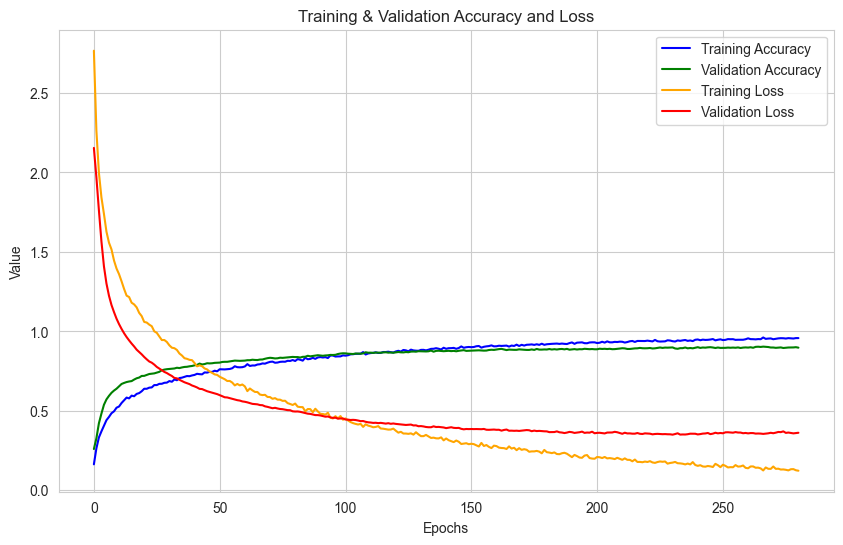

In [209]:



# 5️⃣ Compilazione del Modello
#model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6️⃣ Early Stopping + Reduce LR per migliorare la generalizzazione
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

# 7️⃣ Allenamento del Modello
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=400, batch_size=128, callbacks=[early_stopping], verbose=1)

# 8️⃣ Valutazione
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print("The test Loss is :",test_loss)

# 9️⃣ Grafico Unico con Training Accuracy, Validation Accuracy, Training Loss, Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.plot(history.history['loss'], label='Training Loss', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')

plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Training & Validation Accuracy and Loss")
plt.legend()
plt.grid(True)
plt.show()


Analisi delle Curve
🔵 Training Accuracy (Blu)

Aumenta progressivamente, il che indica che il modello sta imparando bene sui dati di training.
Si stabilizza dopo un certo numero di epoche, segnale che il modello ha raggiunto un livello ottimale.
🟢 Validation Accuracy (Verde)

Segue un andamento simile alla training accuracy, ma con un valore leggermente inferiore.
Il fatto che non ci sia un forte calo rispetto alla training accuracy indica che non c'è overfitting significativo.
🟠 Training Loss (Arancione)

Diminuisce rapidamente nelle prime epoche, segno che il modello sta ottimizzando i pesi per ridurre l'errore.
Continua a diminuire ma a ritmo più lento dopo un certo punto.
🔴 Validation Loss (Rosso)

Segue un andamento simile alla training loss, il che è un ottimo segnale!
Se la validation loss aumentasse mentre la training loss continua a diminuire, significherebbe overfitting (il modello impara troppo i dettagli dei dati di training e non generalizza bene).
📊 Cosa Indicano le Curve?
✅ Il modello è ben bilanciato, perché:

Accuracy (training e validation) cresce e si stabilizza → il modello impara bene.
Loss (training e validation) diminuisce e si stabilizza → il modello riduce l’errore in modo corretto.
Non c’è overfitting evidente, perché le curve di training e validation sono simili.